# Computational Thinking

## The Essence of Computational Thinking


Computational thinking is a fundamental methodology for solving problems by reformulating them in ways that enable systematic, step-by-step execution [@wing2006computational; @weintrop2016defining]. Rather than a programming technique, it represents a way of approaching problems in the computational age. The methodology rests on four interconnected practices: breaking problems into smaller subproblems (decomposition), representing physical systems as mathematical models (abstraction), expressing solutions as iterative procedures (algorithmic thinking), and exploring system behavior through step-by-step simulations (modeling and simulation). When analyzing a damped pendulum, we decompose the motion into force calculations and state updates at each time step, abstract the physical system as ordinary differential equations, design an algorithm that repeatedly computes and updates the system state, and run simulations to generate trajectories that reveal the pendulum's behavior over time.


### A Fundamental Shift, Not a Shortcut


This approach is not a shortcut but a fundamental shift in problem-solving methodology. Consider a pendulum swinging with air resistance at large angles: the governing nonlinear differential equation admits no closed-form solution in elementary functions. Traditional analytical methods reach an impasse, but computational thinking circumvents this entirely by treating the system as something to be simulated rather than solved symbolically [@burden2015numerical]. The principle is simple: humans excel at modeling physical situations and interpreting results, while computers excel at rapid, tireless calculation. By delegating mechanical computation to machines, we tackle problems of complexity far beyond purely analytical methods.


### Computational Thinking in Engineering: The Iterative Approach



In engineering and applied mathematics, computational thinking transforms continuous physical processes into discrete, iterative steps. This iterative process constitutes the algorithm that solves the problem.



A continuous process, such as the motion of an object over time, is decomposed into a sequence of small time steps $\Delta t$. We recognize that the same physical laws apply at every step: the state at time $(t + \Delta t)$ is determined by the state at time $t$. This repeating pattern enables an algorithmic solution through a loop that calculates state changes and updates the system until a desired condition is met. The system is encoded as update rules on state variables, and these rules execute repeatedly to generate a numerical trajectory for analysis and visualization.


### An Engineering Example: A Pendulum with Air Resistance



A damped pendulum illustrates both the limitations of analytical methods and the strength of computational thinking. The governing differential equation $mL\ddot{\theta} + cL\dot{\theta} + mg\sin(\theta) = 0$ is nonlinear due to the $\sin(\theta)$ term, preventing closed-form solution for large angles. The computational approach bypasses this impasse by discretizing time into small steps $\Delta t$ and treating angular acceleration as approximately constant over each step. At each time step, we calculate the angular acceleration $\alpha = -(c/m)\dot{\theta} - (g/L)\sin(\theta)$ from the current state, update the angular velocity $\omega_{\text{new}} = \omega + \alpha \Delta t$, and update the angle $\theta_{\text{new}} = \theta + \omega_{\text{new}} \Delta t$. This iterative process generates a numerical trajectory that would otherwise be unobtainable, demonstrating how computational thinking provides solutions when traditional analytical techniques fail.



### Intuition and Modularity: The Brake Pad Example



Beyond tackling analytically difficult problems, the computational approach often proves more intuitive. Consider calculating a car's stopping distance when the brake pad friction coefficient $\mu$ decreases with temperature. An analytical solution requires solving coupled integral-differential equations describing the feedback between energy dissipation, temperature, and braking force. The computational approach simply simulates cause and effect: at each time step, look up $\mu$ from the current temperature, compute the braking force $F = \mu F_{\text{normal}}$, calculate deceleration and distance traveled, convert work to heat, and update the temperature. Each line of code mirrors a physical process, making the model transparent and easily modified.


### Applying Computational Thinking: A Practical Workflow



Computational thinking becomes a repeatable workflow structured as **Formulate–Solve–Analyze**. In the formulation phase, we translate real-world problems into mathematical and computational models by defining variables, coordinates, and governing principles. The solution phase delegates mechanical calculation to appropriate tools: symbolic algebra systems, numerical libraries, or custom time-stepping schemes. The analysis phase returns to human judgment: we visualize results through plots and animations, validate solutions by checking units and limiting cases, and interpret what the results reveal about system behavior. This workflow transforms computational thinking from an abstract concept into practical methodology.


## Example 1 - boat navigation

Let the coordinates be in km. A boat is at point (-40, -20) and is headed toward the point (50, 80) with a speed of 10 km/h. Compute the point where the boat needs to make a $60^\circ$ turn to continue in a straight line towards the harbor at the point (40, 50). How long will it take the boat to reach the harbor?

### Formulation



We can solve this problem geometrically. Let the starting point be $P_1 = (-40, -20)$, the initial heading point be $P_2 = (50, 80)$, the harbor be $P_H = (40, 50)$, and the unknown turning point be $P_T = (x_t, y_t)$.


It's always a good idea to sketch the situation to visualize the problem.

In [87]:
#| echo: false
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from mechanicskit import display_labeled_latex

%config InlineBackend.figure_format = 'svg'

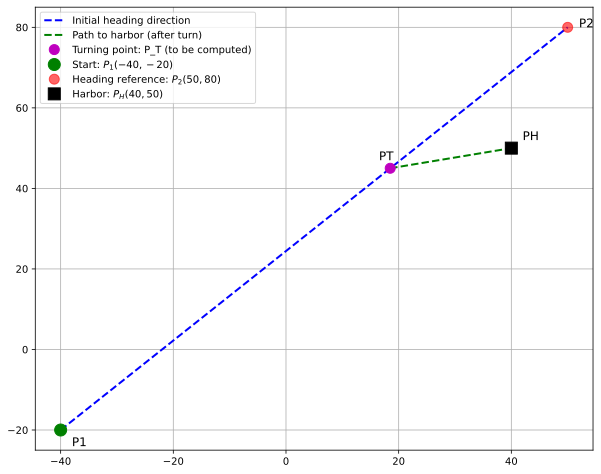

In [88]:
#| code-fold: true
#| classes: size-80
P1 = np.array([-40, -20])  # Starting point
P2 = np.array([50, 80])     # Initial heading point
P_harbor = np.array([40, 50])  # Harbor (destination)

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)

dir_vector = P2 - P1
ax.plot(*zip(*[P1, P1 + dir_vector]),
        'b--', linewidth=2, label='Initial heading direction')

P_turn_approx = P1 + dir_vector * 0.65

ax.plot([P_turn_approx[0], P_harbor[0]],
        [P_turn_approx[1], P_harbor[1]],
        'g--', linewidth=2, label='Path to harbor (after turn)')

ax.plot(P_turn_approx[0], P_turn_approx[1], 'mo', markersize=10, 
        label='Turning point: P_T (to be computed)')

ax.plot(P1[0], P1[1], 'go', markersize=12, label='Start: $P_1(-40, -20)$')
ax.plot(P2[0], P2[1], 'ro', markersize=10, alpha=0.6, label='Heading reference: $P_2(50, 80)$')
ax.plot(P_harbor[0], P_harbor[1], 'ks', markersize=12, label='Harbor: $P_H(40, 50)$')

ax.text(P1[0]+2, P1[1]-4, 'P1', fontsize=12)
ax.text(P2[0]+2, P2[1], 'P2', fontsize=12)
ax.text(P_harbor[0]+2, P_harbor[1]+2, 'PH', fontsize=12)
ax.text(P_turn_approx[0]-2, P_turn_approx[1]+2, 'PT', fontsize=12)
ax.legend()


Here, we have drawn the known points and the trajectory of the boat. The unknown turning point $P_T$ lies somewhere on the line segment between $P_1$ and $P_2$. We have modeled this turning point as 65% of the way from $P_1$ to $P_2$ just for illustration; the actual turning point will be computed below.

65% of the way from $P_1$ to $P_2$ is the same as starting at $P_1$ and going 65% of the way along the vector $P_2 - P_1$. We start simple: Let's parameterize the turning point using the parameter $t$ such that 

$$
P_T = P_1 + t(P_2 - P_1)
$$


But we also need to fulfill the $60^\circ$ turn condition. Let $\boldsymbol v_{1} = P_T - P_1$ and $\boldsymbol v_{2} = P_H - P_T$. The angle between the vectors $\boldsymbol v_{1}$ and $\boldsymbol v_{2}$ must be $60^\circ$. Using the dot product formula, we have:

$$
\boldsymbol{v_1} \cdot \boldsymbol{v_2} = \|\boldsymbol{v_1}\| \|\boldsymbol{v_2}\| \cos(60^\circ)
$$

Once we solve for $t$, we can compute the turning point $P_T$. Finally, we can compute the total distance from $P_1$ to $P_T$ to $P_H$ and divide by the speed to get the time taken. We can delegate the algebraic manipulation to SymPy.

::: {.callout-note}
This formulation phase is crucial! It is often the hard part and where students get lost in computation. Do not start computing too early! Formulate a strategy first! Start with a sketch if applicable. Explicitly write down what you know and what you need to find. Identify the variables and parameters. Then formulate a plan to connect the knowns to the unknowns. Find equations that relate the variables. Only then start computing, starting with intial algebraic expansions using sympy. To grasp the problem, identifying unknowns and knowns, and writing down the equations is often more important than the final numerical answer. Do not rush into coding!

Always try to keep things symbolic as long as possible. Numerical values can be plugged in at the end.
:::

In [89]:
#| code-fold: false
t = sp.symbols('t', real=True)

P1 = sp.Matrix([-40, -20])
P2 = sp.Matrix([50, 80])
P_harbor = sp.Matrix([40, 50])
dir_vector = P2 - P1
P_T = P1 + t * dir_vector

In [90]:
#| echo: false
display_labeled_latex(r"\boldsymbol P_T=", P_T)

<IPython.core.display.Latex object>

In [91]:
#| code-fold: false
v_1 = P2 - P1
v_2 = P_harbor - P_T

eq = sp.Eq(v_1.dot(v_2), v_1.norm() * v_2.norm() * sp.cos(60 * sp.pi / 180))
eq

Eq(14200 - 18100*t, 5*sqrt(181)*sqrt((90*t - 80)**2 + (100*t - 70)**2))

In [92]:
#| code-fold: false
sol = sp.solve(eq, t)
t_turn = sol[0]
t_turn.evalf()

0.730304118363405

In [93]:
#| code-fold: false
P_turn = P1 + t_turn * dir_vector
P_turn.evalf()

Matrix([
[25.7273706527065],
[53.0304118363405]])

In [94]:
#| code-fold: false
v = 10 # km/h
t_to_turn = (v_1.norm() / v).evalf() # hours to reach turning point
t_to_harbor = (v_2.norm() / v).subs(t,t_turn).evalf() # hours from turning point to harbor
t_total = t_to_turn + t_to_harbor

print(f"Time to turn: {t_to_turn:.2f} hours")
print(f"Time to harbor after turn: {t_to_harbor:.2f} hours")
print(f"Total time: {t_total:.2f} hours")

Time to turn: 13.45 hours
Time to harbor after turn: 1.46 hours
Total time: 14.91 hours


### Verification

Finally, we plot the trajectory to visually verify that our solution is correct. The plot should show the boat starting at $P_1$, heading towards $P_2$, making a turn at the calculated point $P_T$, and then proceeding to the harbor $P_H$. This confirms that our mathematical model and its solution accurately reflect the physical reality described in the problem.

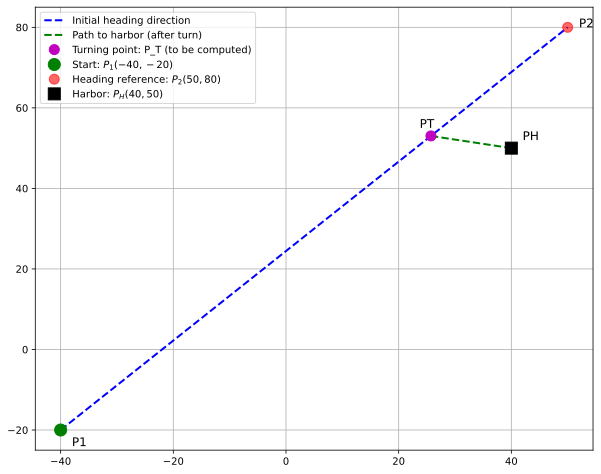

In [95]:
#| code-fold: true
#| classes: size-80
P1 = np.array([-40, -20])  # Starting point
P2 = np.array([50, 80])     # Initial heading point
P_harbor = np.array([40, 50])  # Harbor (destination)

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)

dir_vector = P2 - P1
ax.plot(*zip(*[P1, P1 + dir_vector]),
        'b--', linewidth=2, label='Initial heading direction')

P_turn_exact = P_turn.evalf()

ax.plot([P_turn_exact[0], P_harbor[0]],
        [P_turn_exact[1], P_harbor[1]],
        'g--', linewidth=2, label='Path to harbor (after turn)')

ax.plot(P_turn_exact[0], P_turn_exact[1], 'mo', markersize=10, 
        label='Turning point: P_T (to be computed)')

ax.plot(P1[0], P1[1], 'go', markersize=12, label='Start: $P_1(-40, -20)$')
ax.plot(P2[0], P2[1], 'ro', markersize=10, alpha=0.6, label='Heading reference: $P_2(50, 80)$')
ax.plot(P_harbor[0], P_harbor[1], 'ks', markersize=12, label='Harbor: $P_H(40, 50)$')

ax.text(P1[0]+2, P1[1]-4, 'P1', fontsize=12)
ax.text(P2[0]+2, P2[1], 'P2', fontsize=12)
ax.text(P_harbor[0]+2, P_harbor[1]+2, 'PH', fontsize=12)
ax.text(P_turn_exact[0]-2, P_turn_exact[1]+2, 'PT', fontsize=12)
ax.legend()


## Example 2 - boat navigation with a current

Lets revisit example 1, but now assume that there is a current flowing in the positive x-direction at 5 km/h. We are instructed to keep the trajectory $\overrightarrow{P_1P_2}$. Compute the point where the boat needs to make a $60^\circ$ turn to continue in a straight line towards the harbor at the point (40, 50). How long will it take the boat to reach the harbor?


### Formulation

Now there is a current in the positive x-direction at 5 km/h. This means that the boat's velocity relative to the water must be adjusted to account for the current. The boat's effective velocity vector $\boldsymbol{v}_{\text{eff}}$ is the sum of its velocity vector $\boldsymbol{v}_{\text{boat}}$ and the current vector $\boldsymbol{v}_{\text{current}} = (5, 0)$ km/h.

The difference from Example 1 is that while we want the ground track to follow $\overrightarrow{P_1P_2}$ (same as before), the boat must now steer in a different direction to compensate for the current. 

On the first leg, let the ground velocity be $\boldsymbol{v}_{\text{ground},1} = s_1 \boldsymbol{e}_1$ where $\boldsymbol{e}_1$ is the unit vector along $\overrightarrow{P_1P_2}$ and $s_1$ is the unknown ground speed. The boat velocity satisfies:

$$\boldsymbol{v}_{\text{ground},1} = \boldsymbol{v}_{\text{boat},1} + \boldsymbol{v}_{\text{current}}$$

with the constraint $\|\boldsymbol{v}_{\text{boat},1}\| = 10$ km/h. This allows us to solve for $s_1$.

Let's sketch the situation to visualize how the current affects the boat's heading.

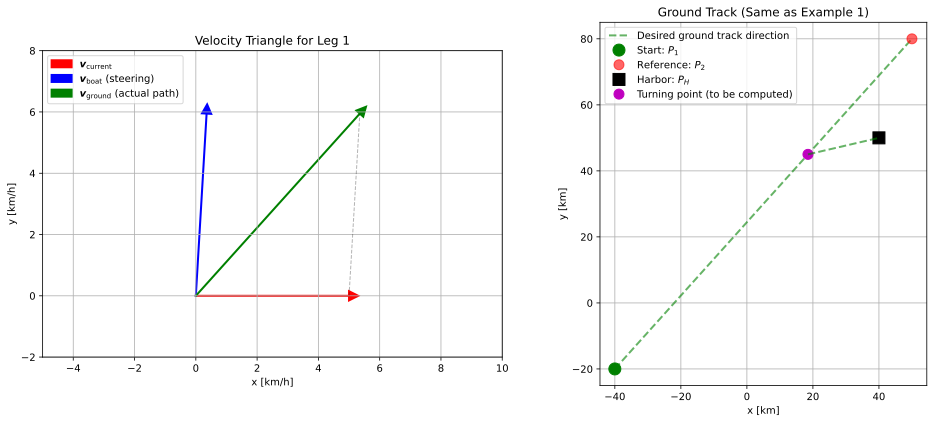

In [96]:
#| code-fold: true
#| classes: size-100
# Sketch showing velocity triangle
P1 = np.array([-40, -20])
P2 = np.array([50, 80])
P_harbor = np.array([40, 50])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Velocity triangle
ax[0].set_title('Velocity Triangle for Leg 1')
ax[0].set_aspect('equal')
ax[0].grid(True)

# Direction of desired ground track
dir_ground = (P2 - P1) / np.linalg.norm(P2 - P1)

# For illustration, assume some ground speed
v_ground_approx = 8 * dir_ground  # Approximate
v_current = np.array([5, 0])
v_boat_approx = v_ground_approx - v_current

origin = np.array([0, 0])
scale = 1

# Draw velocity vectors from origin
ax[0].arrow(origin[0], origin[1], v_current[0]*scale, v_current[1]*scale,
           head_width=0.3, head_length=0.3, fc='red', ec='red',
           linewidth=2, label='$\\boldsymbol{v}_{\\mathrm{current}}$')
ax[0].arrow(origin[0], origin[1], v_boat_approx[0]*scale, v_boat_approx[1]*scale,
           head_width=0.3, head_length=0.3, fc='blue', ec='blue',
           linewidth=2, label='$\\boldsymbol{v}_{\\mathrm{boat}}$ (steering)')
ax[0].arrow(origin[0], origin[1], v_ground_approx[0]*scale, v_ground_approx[1]*scale,
           head_width=0.3, head_length=0.3, fc='green', ec='green',
           linewidth=2, label='$\\boldsymbol{v}_{\\mathrm{ground}}$ (actual path)')

# Draw the triangle
ax[0].plot([v_current[0]*scale, v_ground_approx[0]*scale], 
           [v_current[1]*scale, v_ground_approx[1]*scale],
           'k--', alpha=0.3, linewidth=1)

ax[0].set_xlabel('x [km/h]')
ax[0].set_ylabel('y [km/h]')
ax[0].legend(loc='upper left')
ax[0].set_xlim(-5, 10)
ax[0].set_ylim(-2, 8)

# Right plot: Ground track
ax[1].set_title('Ground Track (Same as Example 1)')
ax[1].grid(True)
ax[1].set_aspect('equal')

# Show the desired ground track
ax[1].plot([P1[0], P2[0]], [P1[1], P2[1]],
          'g--', linewidth=2, alpha=0.6, label='Desired ground track direction')

# Show points
ax[1].plot(P1[0], P1[1], 'go', markersize=12, label='Start: $P_1$')
ax[1].plot(P2[0], P2[1], 'ro', markersize=10, alpha=0.6, label='Reference: $P_2$')
ax[1].plot(P_harbor[0], P_harbor[1], 'ks', markersize=12, label='Harbor: $P_H$')

# Approximate turning point
P_turn_approx = P1 + 0.65 * (P2 - P1)
ax[1].plot(P_turn_approx[0], P_turn_approx[1], 'mo', markersize=10,
          label='Turning point (to be computed)')
ax[1].plot([P_turn_approx[0], P_harbor[0]], [P_turn_approx[1], P_harbor[1]],
          'g--', linewidth=2, alpha=0.6)

ax[1].set_xlabel('x [km]')
ax[1].set_ylabel('y [km]')
ax[1].legend(loc='upper left')

plt.tight_layout()

In [106]:
#| code-fold: false
# Define symbolic variables
s1, t1 = sp.symbols('s_1 t_1', real=True, positive=True)

# Known quantities
P1 = sp.Matrix([-40, -20])
P2 = sp.Matrix([50, 80])
P_H = sp.Matrix([40, 50])
v_current = sp.Matrix([5, 0])
v_boat_speed = 10  # km/h

# Direction unit vector for first leg (along P1 to P2)
e1 = (P2 - P1).normalized()

# Leg 1: Ground velocity along e1
v_ground_1 = s1 * e1
v_boat_1 = v_ground_1 - v_current

# Turning point
P_T = P1 + t1 * v_ground_1
P_T

Matrix([
[ 9*sqrt(181)*s_1*t_1/181 - 40],
[10*sqrt(181)*s_1*t_1/181 - 20]])

In [107]:
#| code-fold: false
v_ground_1

Matrix([
[ 9*sqrt(181)*s_1/181],
[10*sqrt(181)*s_1/181]])

In [108]:
#| code-fold: false
v_boat_1

Matrix([
[9*sqrt(181)*s_1/181 - 5],
[   10*sqrt(181)*s_1/181]])

We need to satisfy: $|\boldsymbol{v}_{\text{boat},1}| = 10$

In [109]:
#| code-fold: false
# Constraint 1: Boat speed on leg 1
eq1 = sp.Eq(v_boat_1.norm(), v_boat_speed)
eq1

Eq(sqrt(100*s_1**2/181 + (9*sqrt(181)*s_1/181 - 5)**2), 10)

From this we can solve for $s_1$.

In [110]:
#| code-fold: false
# Solve for s1
sol_s1 = sp.solve(eq1, s1)
print(f"Solutions for s1: {len(sol_s1)} found")
for i, s in enumerate(sol_s1):
    print(f"s1[{i}] = {s.evalf():.4f} km/h")

Solutions for s1: 1 found
s1[0] = 12.6286 km/h


In [156]:
#| code-fold: false
v_ground_1 = v_ground_1.subs(s1, sol_s1[0].evalf()).evalf()
v_ground_1

Matrix([
[8.44806430779951],
[9.38673811977723]])

The turning point is $P_T = P_1 + t_1 \boldsymbol{v}_{\text{ground},1} = P_1 + t_1 s_1 \boldsymbol{e}_1$.

In [158]:
#| code-fold: false
P_T = P1 + t1 * v_ground_1
P_T = P_T.subs(s1, sol_s1[0].evalf())
P_T

Matrix([
[8.44806430779951*t_1 - 40],
[9.38673811977723*t_1 - 20]])

For leg 2 we have the ground velocity $\boldsymbol{v}_{\text{ground},2} = s_2 \boldsymbol{e}_2$ where $\boldsymbol{e}_2$ is the unit vector along $\overrightarrow{P_T P_H}$ and $s_2$ is the unknown ground speed. The boat velocity satisfies:

$$\boldsymbol{v}_{\text{ground},2} = \boldsymbol{v}_{\text{boat},2} + \boldsymbol{v}_{\text{current}}$$

$$
\boldsymbol{v}_{\text{boat},2} = \boldsymbol{v}_{\text{ground},2} - \boldsymbol{v}_{\text{current}}
$$

In [159]:
#| code-fold: false
# Leg 2: Ground velocity points toward harbor
s2 = sp.symbols('s_2', real=True, positive=True)
e2 = (P_H - P_T).normalized()
v_ground_2 = s2 * e2
v_boat_2 = v_ground_2 - v_current
v_boat_2


Matrix([
[s_2*(80 - 8.44806430779951*t_1)/sqrt((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2) - 5],
[    s_2*(70 - 9.38673811977723*t_1)/sqrt((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2)]])

$$
|\boldsymbol{v}_{\text{boat},2}| = \sqrt{\boldsymbol{v}_{\text{boat},2} \cdot \boldsymbol{v}_{\text{boat},2}}= 10
$$

In [160]:
#| code-fold: false
eq2 = sp.Eq(sp.sqrt(v_boat_2.dot(v_boat_2)), v_boat_speed)
eq2

Eq(sqrt(s_2**2*(70 - 9.38673811977723*t_1)**2/((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2) + (s_2*(80 - 8.44806430779951*t_1)/sqrt((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2) - 5)**2), 10)

$$
\boldsymbol{v}_{\text{ground},1} \cdot \boldsymbol{v}_{\text{ground},2} = |\boldsymbol{v}_{\text{ground},1}| |\boldsymbol{v}_{\text{ground},2}| \cos(60^\circ)
$$

In [161]:
#| code-fold: false
eq3 = sp.Eq(v_ground_1.dot(v_ground_2),
            v_ground_1.norm() * v_ground_2.norm() * sp.cos(60 * sp.pi / 180))
eq3

Eq(9.38673811977723*s_2*(70 - 9.38673811977723*t_1)/sqrt((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2) + 8.44806430779951*s_2*(80 - 8.44806430779951*t_1)/sqrt((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2), 6.31428228459092*sqrt(s_2**2*(8.44806430779951*t_1 - 80)**2/((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2) + s_2**2*(9.38673811977723*t_1 - 70)**2/((8.44806430779951*t_1 - 80)**2 + (9.38673811977723*t_1 - 70)**2)))

Now we have two equations with two unknowns ($t_1$ and $s_2$). However, these equations involve normalized vectors and are highly nonlinear. Attempting symbolic solving with `sp.solve` takes too long time, does not find a solution or produces huge output (try it!). Instead, we use **numerical solving** with `sp.nsolve`



Notice that `s2, t1 = sp.nsolve([eq2, eq3], (s2, t1), (s2_guess, t1_guess))` requires initial guesses for the unknowns. Good initial guesses are important for convergence of numerical solvers. Here we can use the values from Example 1 as initial guesses since the current is not too strong. We notice how the values are sensitive to the initial guesses. Choosing bad initial guesses may lead to divergence or convergence to wrong solutions. This is a common issue with numerical solvers.

In [162]:
#| code-fold: false
s2, t1 = sp.symbols('s_2 t_1', real=True, positive=True)
s2_solution, t1_solution = sp.nsolve([eq2, eq3], (s2, t1), (10, 5))
print(f"s2 = {s2_solution:.4f} km/h")
print(f"t1 = {t1_solution:.4f} hours")

s2 = 14.8369 km/h
t1 = 7.7802 hours


Another way is to `scipy.optimize.fsolve`, which is a purely numerical method, that does not depend on symbolic manipulation. This is often more robust for highly nonlinear problems.

In [163]:
#| code-fold: false
# These equations are highly nonlinear - use numerical solving instead of symbolic
# We need initial guesses. From Example 1, we know t1 ≈ 9.8 hours on first leg
# and the turning point is roughly 65% of the way, so for a slower ground speed we expect longer time
# Good initial guesses: t1 ≈ 11 hours, s2 ≈ 10 km/h

import scipy.optimize as opt

# Convert SymPy equations to numerical functions
def equations(vars):
    t1_val, s2_val = vars
    
    # Substitute numerical values into the symbolic equations
    eq2_num = float(eq2.lhs.subs([(t1, t1_val), (s2, s2_val)]).evalf()) - 10
    eq3_lhs = float(eq3.lhs.subs([(t1, t1_val), (s2, s2_val)]).evalf())
    eq3_rhs = float(eq3.rhs.subs([(t1, t1_val), (s2, s2_val)]).evalf())
    eq3_num = eq3_lhs - eq3_rhs
    
    return [eq2_num, eq3_num]

# Initial guess
initial_guess = [5.0, 10.0]

# Solve numerically
print("Solving system numerically...")
solution = opt.fsolve(equations, initial_guess)
t1_solution, s2_solution = solution

print(f"\nNumerical solution:")
print(f"t1 = {t1_solution:.4f} hours")
print(f"s2 = {s2_solution:.4f} km/h")

# Verify the solution
residuals = equations(solution)
print(f"\nResiduals (should be close to zero):")
print(f"eq2 residual: {residuals[0]:.2e}")
print(f"eq3 residual: {residuals[1]:.2e}")

Solving system numerically...

Numerical solution:
t1 = 7.7802 hours
s2 = 14.8369 km/h

Residuals (should be close to zero):
eq2 residual: 1.42e-14
eq3 residual: -1.12e-12


In [164]:
#| code-fold: false
# Compute the turning point
P_T_solution = P_T.subs(t1, t1_solution)
print("Turning point coordinates:")
print(f"P_T = ({float(P_T_solution[0].evalf()):.2f}, {float(P_T_solution[1].evalf()):.2f}) km")

# Compute distance and time on second leg
dist_2 = float((P_H - P_T_solution).norm().evalf())
t2_solution = dist_2 / s2_solution

print(f"\nDistance on second leg: {dist_2:.2f} km")
print(f"Time on second leg: t2 = {t2_solution:.4f} hours")

# Total time
t_total = t1_solution + t2_solution
print(f"\nTotal time to harbor: {t_total:.2f} hours")

# Compare with Example 1
print(f"\nComparison with Example 1 (no current):")
print(f"  Example 1 total time: 14.91 hours")
print(f"  Example 2 total time: {t_total:.2f} hours")
print(f"  Difference: {(t_total - 14.91):.2f} hours")

Turning point coordinates:
P_T = (25.73, 53.03) km

Distance on second leg: 14.59 km
Time on second leg: t2 = 0.9834 hours

Total time to harbor: 8.76 hours

Comparison with Example 1 (no current):
  Example 1 total time: 14.91 hours
  Example 2 total time: 8.76 hours
  Difference: -6.15 hours


### Verification

We plot the results to visualize the solution. The plot shows the ground track (green), the boat's steering direction (blue dashed), and the velocity triangle illustrating how the current affects navigation.

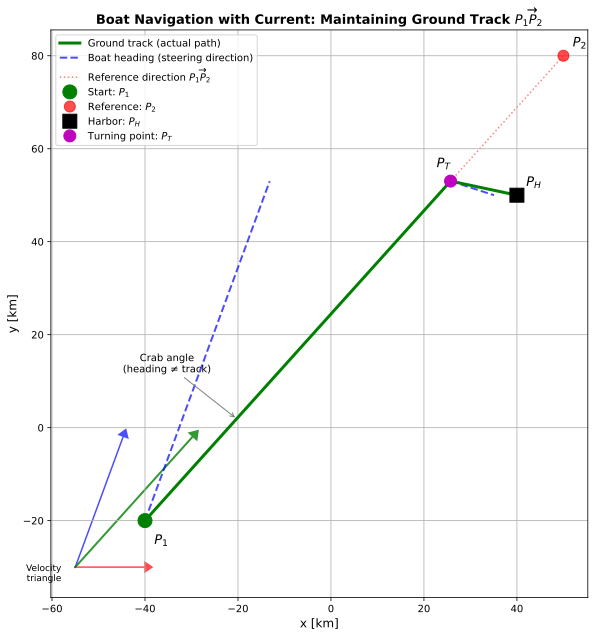

In [165]:
#| code-fold: true
#| classes: size-80
# Convert to numerical values for plotting
P1_num = np.array([-40, -20])
P2_num = np.array([50, 80])
P_H_num = np.array([40, 50])
v_current_num = np.array([5, 0])

s1_num = float(sol_s1[0].evalf())

# Compute turning point
e1_num = (P2_num - P1_num) / np.linalg.norm(P2_num - P1_num)
P_T_num = P1_num + t1_solution * s1_num * e1_num

# Compute velocities
v_ground_1_num = s1_num * e1_num
v_boat_1_num = v_ground_1_num - v_current_num

e2_num = (P_H_num - P_T_num) / np.linalg.norm(P_H_num - P_T_num)
v_ground_2_num = s2_solution * e2_num
v_boat_2_num = v_ground_2_num - v_current_num

fig, ax = plt.subplots(figsize=(12, 9))
ax.grid(True)
ax.set_aspect('equal')

# Plot the ground track (actual path)
ax.plot([P1_num[0], P_T_num[0]], [P1_num[1], P_T_num[1]],
        'g-', linewidth=3, label='Ground track (actual path)', zorder=3)
ax.plot([P_T_num[0], P_H_num[0]], [P_T_num[1], P_H_num[1]],
        'g-', linewidth=3, zorder=3)

# Plot steering directions (boat heading relative to water)
steering_end_1 = P1_num + v_boat_1_num * t1_solution
ax.plot([P1_num[0], steering_end_1[0]], [P1_num[1], steering_end_1[1]],
        'b--', linewidth=2, alpha=0.7, label='Boat heading (steering direction)', zorder=2)

steering_end_2 = P_T_num + v_boat_2_num * t2_solution
ax.plot([P_T_num[0], steering_end_2[0]], [P_T_num[1], steering_end_2[1]],
        'b--', linewidth=2, alpha=0.7, zorder=2)

# Plot the reference line P1-P2
ax.plot([P1_num[0], P2_num[0]], [P1_num[1], P2_num[1]],
        'r:', linewidth=1.5, alpha=0.5, label='Reference direction $\\overrightarrow{P_1P_2}$', zorder=1)

# Plot velocity vectors at starting point (scaled for visibility)
scale_v = 3
origin_v = P1_num + np.array([-15, -10])  # Offset for clarity
ax.arrow(origin_v[0], origin_v[1], v_boat_1_num[0]*scale_v, v_boat_1_num[1]*scale_v,
         head_width=2, head_length=1.5, fc='blue', ec='blue',
         linewidth=1.5, alpha=0.7)
ax.arrow(origin_v[0], origin_v[1], v_current_num[0]*scale_v, v_current_num[1]*scale_v,
         head_width=2, head_length=1.5, fc='red', ec='red',
         linewidth=1.5, alpha=0.7)
ax.arrow(origin_v[0], origin_v[1], v_ground_1_num[0]*scale_v, v_ground_1_num[1]*scale_v,
         head_width=2, head_length=1.5, fc='green', ec='green',
         linewidth=2, alpha=0.8)
ax.text(origin_v[0]-3, origin_v[1]-3, 'Velocity\ntriangle', fontsize=9, ha='right')

# Plot points
ax.plot(P1_num[0], P1_num[1], 'go', markersize=14, label='Start: $P_1$', zorder=4)
ax.plot(P2_num[0], P2_num[1], 'ro', markersize=11, alpha=0.7, label='Reference: $P_2$', zorder=4)
ax.plot(P_H_num[0], P_H_num[1], 'ks', markersize=14, label='Harbor: $P_H$', zorder=4)
ax.plot(P_T_num[0], P_T_num[1], 'mo', markersize=12, label='Turning point: $P_T$', zorder=4)

# Add labels
ax.text(P1_num[0]+2, P1_num[1]-5, '$P_1$', fontsize=13, fontweight='bold')
ax.text(P2_num[0]+2, P2_num[1]+2, '$P_2$', fontsize=13, fontweight='bold')
ax.text(P_H_num[0]+2, P_H_num[1]+2, '$P_H$', fontsize=13, fontweight='bold')
ax.text(P_T_num[0]-3, P_T_num[1]+3, '$P_T$', fontsize=13, fontweight='bold')

# Add crab angle annotation
mid_point = P1_num + 0.3 * (P_T_num - P1_num)
ax.annotate('Crab angle\n(heading ≠ track)', 
            xy=mid_point, xytext=(mid_point[0]-15, mid_point[1]+10),
            arrowprops=dict(arrowstyle='->', lw=1, color='gray'),
            fontsize=10, ha='center')

ax.set_xlabel('x [km]', fontsize=12)
ax.set_ylabel('y [km]', fontsize=12)
ax.set_title('Boat Navigation with Current: Maintaining Ground Track $\\overrightarrow{P_1P_2}$', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()

The plot reveals the crucial distinction between steering direction and ground track when navigating in a current. The green solid line shows the boat's actual path over the ground, which we intentionally maintain along $\overrightarrow{P_1P_2}$ (shown as the red dotted line) to follow the same route as Example 1. The blue dashed lines show where the boat must actually point (steering direction relative to the water) to achieve this ground track.

The velocity triangle inset illustrates the vector addition: the boat's velocity through the water (blue) plus the current (red) equals the ground velocity (green). Notice how the boat must "aim upstream" (point slightly against the current) to maintain its desired course.

Compared to Example 1, the current affects both the travel time and the turning point location. The boat's ground speed changes because it must compensate for the lateral drift. This problem demonstrates a fundamental principle in navigation: maintaining a desired ground track in the presence of a current requires continuous compensation in steering direction, an effect quantified by the crab angle.

**Key insight on numerical solving:** When symbolic solving with `sp.solve` produces enormous expressions or fails entirely (as it did here due to complex normalized vector equations), numerical methods like `scipy.optimize.fsolve` provide a robust alternative. The trade-off is that we must provide reasonable initial guesses, but the solution is fast and accurate for practical engineering purposes.

## Example 3 - boat navigation with a bad navigation system

In this situation the boat is unaware of the current flowing in the positive x-direction at 5 km/h. The boat is at point (-40, -20) and is headed toward the point (50, 80) with a speed of 10 km/h. Assume the boat takes the $60^\circ$ turn at the same coordinates as in example 1. After turning the captain realizes that the boat is drifting off course. Every kilometer they correct their coarse by steering towards the harbor at (40, 50). How long will it take the boat to reach the harbor now? Plot the trajectory of the boat.